In [28]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import zernike
import phase_screen
import reconstruction
import psf_tools
import shwfs_detector


importlib.reload(zernike)
importlib.reload(phase_screen)
importlib.reload(reconstruction)
importlib.reload(psf_tools)
importlib.reload(shwfs_detector)

from zernike import (
    make_pupil_grid,
    generate_zernike_modes,
    number_of_zernike_modes,
)

from phase_screen import fourier_phase_screen

from reconstruction import (
    build_response_matrix,
    measure_slopes,
    reconstruct_wavefront,
    residual_wavefront,
    rms,
)

from psf_tools import (
    compute_psf_from_phase,
    strehl_ratio,
    radial_profile,
)

from shwfs_detector import (
    build_detector_response_matrix,
    measure_centroid_shifts,
    reconstruct_from_centroid_shifts,
)

from reconstruction import synthesize_from_coefficients

In [29]:
N = 256
diameter = 1.0
n_lenslets = 20

X, Y, rho, theta, mask, dx = make_pupil_grid(
    N=N,
    diameter=diameter,
)

W_atm, _, _, _ = fourier_phase_screen(
    N=N,
    delta=dx,
    r0=0.20,
    L0=25.0,
    diameter=diameter,
    seed=4,
    target_rms_rad=1.0,
)

print(f"Atmospheric wavefront RMS: {rms(W_atm, mask):.4f} rad")

Atmospheric wavefront RMS: 0.9999 rad


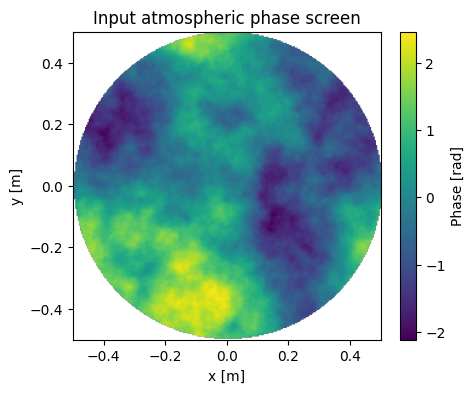

In [30]:
extent = [
    np.nanmin(X),
    np.nanmax(X),
    np.nanmin(Y),
    np.nanmax(Y),
]

plt.figure(figsize=(5, 4))
plt.imshow(
    W_atm,
    extent=extent,
    origin="lower",
)
plt.colorbar(label="Phase [rad]")
plt.title("Input atmospheric phase screen")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()

In [31]:
def run_modal_reconstruction_with_max_order(
    W_true,
    X,
    Y,
    rho,
    theta,
    mask,
    max_radial_order,
    n_lenslets=20,
    noise_std=0.0,
    seed=1,
    rcond=1e-4,
):
    """
    Reconstruct a wavefront using all Zernike modes up to max_radial_order.
    """
    modes = generate_zernike_modes(
        rho,
        theta,
        mask,
        max_radial_order=max_radial_order,
        include_piston=False,
        normalization=True,
    )

    centers, slopes = measure_slopes(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
        noise_std=noise_std,
        seed=seed,
    )

    A, names, _ = build_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
    )

    coeffs, W_rec, residuals, rank, singular_values = reconstruct_wavefront(
        slopes,
        A,
        modes,
        names,
        mask,
        rcond=rcond,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    condition_number = singular_values[0] / singular_values[-1]

    return {
        "modes": modes,
        "names": names,
        "coeffs": coeffs,
        "centers": centers,
        "slopes": slopes,
        "A": A,
        "W_rec": W_rec,
        "residual": res,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": condition_number,
        "n_modes": len(names),
    }

def run_modal_reconstruction_with_max_order_detector(
    W_true,
    X,
    Y,
    rho,
    theta,
    mask,
    max_radial_order,
    n_lenslets=20,
    photons=10000,
    read_noise_e=1.0,
    background_e=2.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    calibration_amplitude=1e-3,
    seed=1,
    rcond=1e-3,
):
    """
    Detector-level modal reconstruction using all Zernike modes up to max order.
    """
    modes = generate_zernike_modes(
        rho,
        theta,
        mask,
        max_radial_order=max_radial_order,
        include_piston=False,
        normalization=True,
    )

    A_det, names, centers, masks_det, reference = build_detector_response_matrix(
        modes,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
        pad_factor=pad_factor,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=detector_window_size,
        calibration_amplitude=calibration_amplitude,
        differential=True,
    )

    _, shifts, diag = measure_centroid_shifts(
        W_true,
        mask,
        X,
        Y,
        n_lenslets=n_lenslets,
        min_fill=0.5,
        pad_factor=pad_factor,
        photons=photons,
        read_noise_e=read_noise_e,
        background_e=background_e,
        threshold_fraction=threshold_fraction,
        subtract_minimum=subtract_minimum,
        detector_window_size=detector_window_size,
        seed=seed,
        reference=reference,
        masks=masks_det,
        centers=centers,
        return_diagnostics=True,
    )

    coeffs, residuals, rank, singular_values = reconstruct_from_centroid_shifts(
        shifts,
        A_det,
        rcond=rcond,
    )

    W_rec = synthesize_from_coefficients(
        coeffs,
        modes,
        names,
        mask,
        remove_mean=True,
    )

    res = residual_wavefront(W_true, W_rec, mask)

    condition_number = singular_values[0] / singular_values[-1]

    return {
        "modes": modes,
        "names": names,
        "coeffs": coeffs,
        "centers": centers,
        "shifts": shifts,
        "A": A_det,
        "W_rec": W_rec,
        "residual": res,
        "input_rms": rms(W_true, mask),
        "residual_rms": rms(res, mask),
        "rank": rank,
        "singular_values": singular_values,
        "condition_number": condition_number,
        "n_modes": len(names),
        "n_valid_centroids": diag["n_valid"],
        "n_total_centroids": diag["n_total"],
    }

In [32]:
max_orders = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10])

results = []

for max_order in max_orders:
    result = run_modal_reconstruction_with_max_order(
        W_atm,
        X,
        Y,
        rho,
        theta,
        mask,
        max_radial_order=int(max_order),
        n_lenslets=n_lenslets,
        noise_std=0.0,
        seed=1,
        rcond=1e-4,
    )

    results.append(result)

    print(
        f"max_order = {max_order:2d}, "
        f"n_modes = {result['n_modes']:3d}, "
        f"rank = {result['rank']:3d}, "
        f"residual RMS = {result['residual_rms']:.4f} rad, "
        f"condition = {result['condition_number']:.2e}"
    )

max_order =  2, n_modes =   5, rank =   5, residual RMS = 0.7561 rad, condition = 1.33e+00
max_order =  3, n_modes =   9, rank =   9, residual RMS = 0.6325 rad, condition = 1.86e+00
max_order =  4, n_modes =  14, rank =  14, residual RMS = 0.5369 rad, condition = 2.39e+00
max_order =  5, n_modes =  20, rank =  20, residual RMS = 0.4647 rad, condition = 3.43e+00
max_order =  6, n_modes =  27, rank =  27, residual RMS = 0.4367 rad, condition = 4.23e+00
max_order =  7, n_modes =  35, rank =  35, residual RMS = 0.4085 rad, condition = 5.75e+00
max_order =  8, n_modes =  44, rank =  44, residual RMS = 0.3908 rad, condition = 6.68e+00
max_order =  9, n_modes =  54, rank =  54, residual RMS = 0.3734 rad, condition = 8.65e+00
max_order = 10, n_modes =  65, rank =  65, residual RMS = 0.3077 rad, condition = 9.55e+00


In [33]:
max_orders_det = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10])

results_det = []

for max_order in max_orders_det:
    result = run_modal_reconstruction_with_max_order_detector(
        W_atm,
        X,
        Y,
        rho,
        theta,
        mask,
        max_radial_order=int(max_order),
        n_lenslets=16,
        photons=10000,
        read_noise_e=1.0,
        background_e=2.0,
        pad_factor=4,
        threshold_fraction=0.02,
        subtract_minimum=True,
        detector_window_size=24,
        seed=1,
        rcond=1e-3,
    )

    results_det.append(result)

    print(
        f"max_order = {max_order:2d}, "
        f"n_modes = {result['n_modes']:3d}, "
        f"rank = {result['rank']:3d}, "
        f"residual RMS = {result['residual_rms']:.4f} rad, "
        f"condition = {result['condition_number']:.2e}, "
        f"valid centroids = {result['n_valid_centroids']}/{result['n_total_centroids']}"
    )

max_order =  2, n_modes =   5, rank =   5, residual RMS = 0.8394 rad, condition = 2.44e+00, valid centroids = 208/208
max_order =  3, n_modes =   9, rank =   9, residual RMS = 0.8024 rad, condition = 1.28e+01, valid centroids = 208/208
max_order =  4, n_modes =  14, rank =  14, residual RMS = 0.6790 rad, condition = 2.07e+01, valid centroids = 208/208
max_order =  5, n_modes =  20, rank =  20, residual RMS = 0.6104 rad, condition = 2.97e+01, valid centroids = 208/208
max_order =  6, n_modes =  27, rank =  27, residual RMS = 0.5300 rad, condition = 3.31e+01, valid centroids = 208/208
max_order =  7, n_modes =  35, rank =  35, residual RMS = 0.5086 rad, condition = 4.52e+01, valid centroids = 208/208
max_order =  8, n_modes =  44, rank =  44, residual RMS = 0.5053 rad, condition = 4.52e+01, valid centroids = 208/208
max_order =  9, n_modes =  54, rank =  54, residual RMS = 0.4775 rad, condition = 5.77e+01, valid centroids = 208/208
max_order = 10, n_modes =  65, rank =  65, residual RMS 

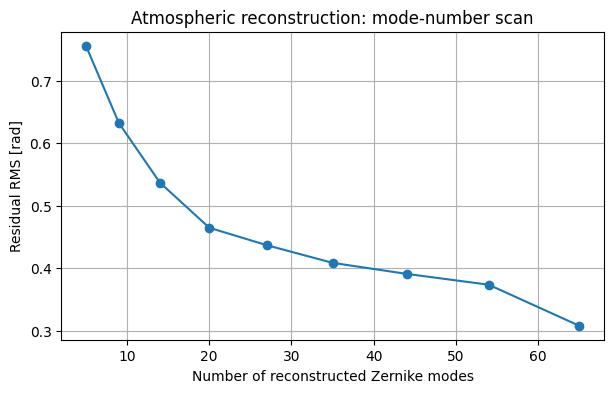

In [34]:
n_modes = np.array([r["n_modes"] for r in results])
residual_rms_values = np.array([r["residual_rms"] for r in results])
condition_values = np.array([r["condition_number"] for r in results])
rank_values = np.array([r["rank"] for r in results])

plt.figure(figsize=(7, 4))

plt.plot(
    n_modes,
    residual_rms_values,
    marker="o",
)

plt.xlabel("Number of reconstructed Zernike modes")
plt.ylabel("Residual RMS [rad]")
plt.title("Atmospheric reconstruction: mode-number scan")
plt.grid(True)
plt.show()

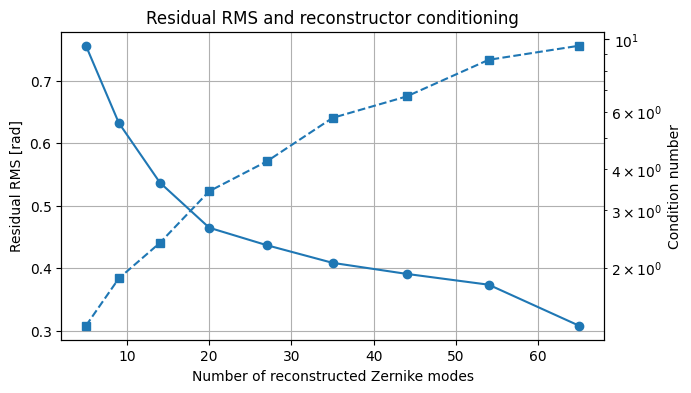

In [35]:
fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(
    n_modes,
    residual_rms_values,
    marker="o",
)
ax1.set_xlabel("Number of reconstructed Zernike modes")
ax1.set_ylabel("Residual RMS [rad]")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.semilogy(
    n_modes,
    condition_values,
    marker="s",
    linestyle="--",
)
ax2.set_ylabel("Condition number")

plt.title("Residual RMS and reconstructor conditioning")
plt.show()

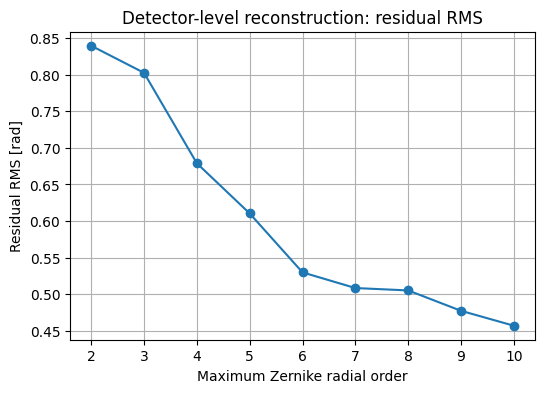

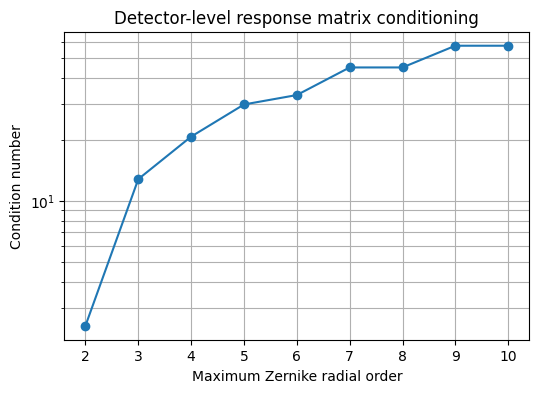

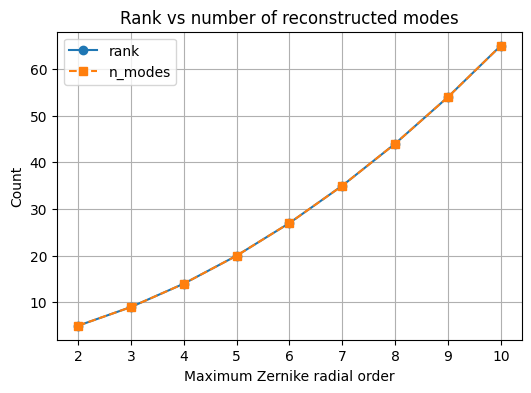

In [36]:
max_orders = np.array([r["n_modes"] * 0 + mo for r, mo in zip(results_det, max_orders_det)])
n_modes_arr = np.array([r["n_modes"] for r in results_det])
rank_arr = np.array([r["rank"] for r in results_det])
residual_rms_arr = np.array([r["residual_rms"] for r in results_det])
condition_arr = np.array([r["condition_number"] for r in results_det])

plt.figure(figsize=(6, 4))
plt.plot(max_orders_det, residual_rms_arr, marker="o")
plt.xlabel("Maximum Zernike radial order")
plt.ylabel("Residual RMS [rad]")
plt.title("Detector-level reconstruction: residual RMS")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(max_orders_det, condition_arr, marker="o")
plt.yscale("log")
plt.xlabel("Maximum Zernike radial order")
plt.ylabel("Condition number")
plt.title("Detector-level response matrix conditioning")
plt.grid(True, which="both")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(max_orders_det, rank_arr, marker="o", label="rank")
plt.plot(max_orders_det, n_modes_arr, marker="s", linestyle="--", label="n_modes")
plt.xlabel("Maximum Zernike radial order")
plt.ylabel("Count")
plt.title("Rank vs number of reconstructed modes")
plt.legend()
plt.grid(True)
plt.show()

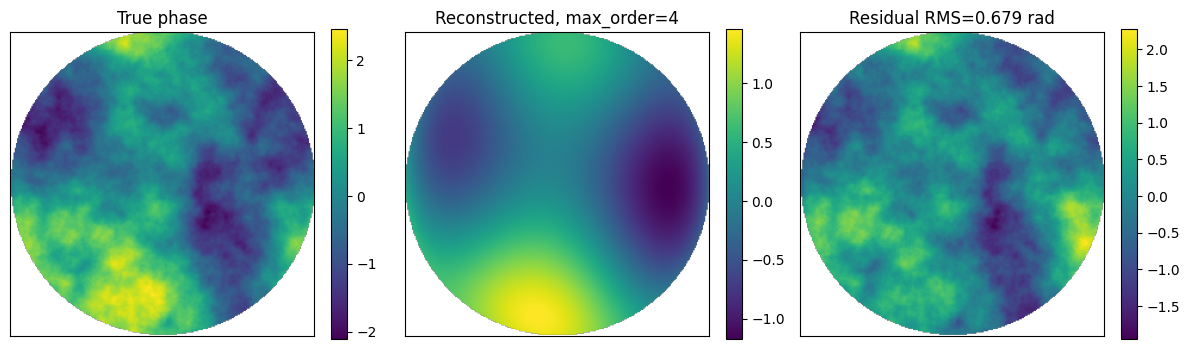

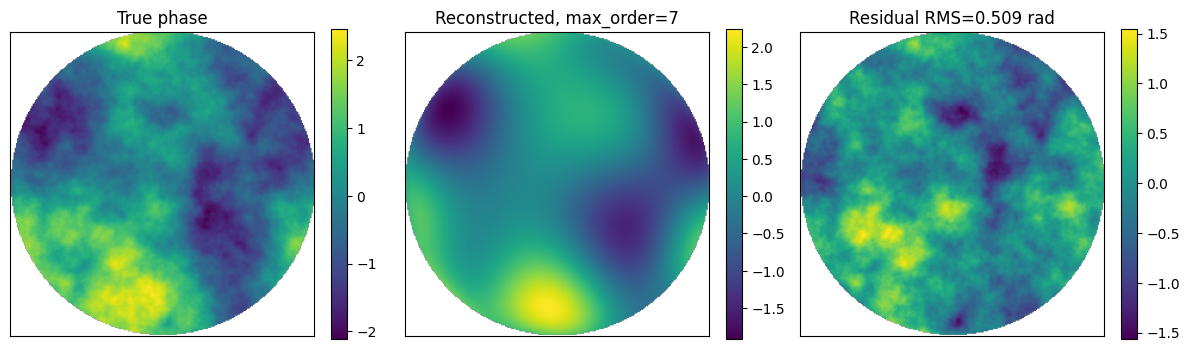

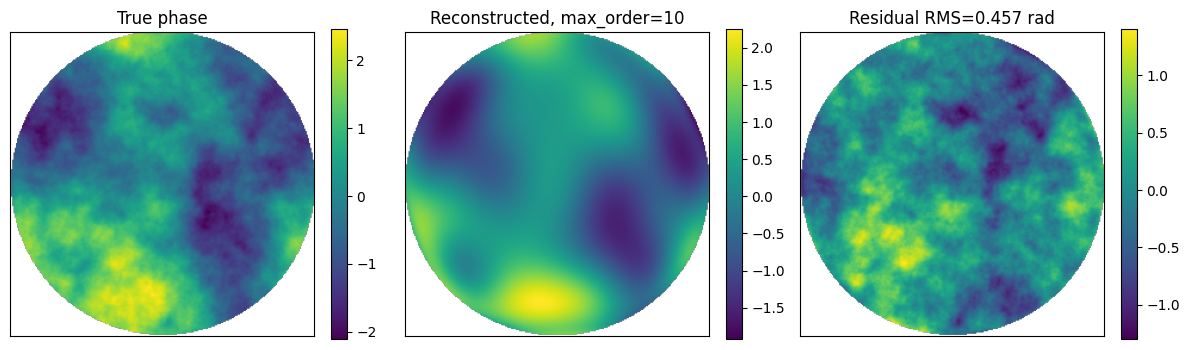

In [37]:
selected_orders = [4, 7, 10]

for order in selected_orders:
    idx = list(max_orders_det).index(order)
    result = results_det[idx]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    im0 = axes[0].imshow(W_atm, origin="lower")
    axes[0].set_title("True phase")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(result["W_rec"], origin="lower")
    axes[1].set_title(f"Reconstructed, max_order={order}")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(result["residual"], origin="lower")
    axes[2].set_title(f"Residual RMS={result['residual_rms']:.3f} rad")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

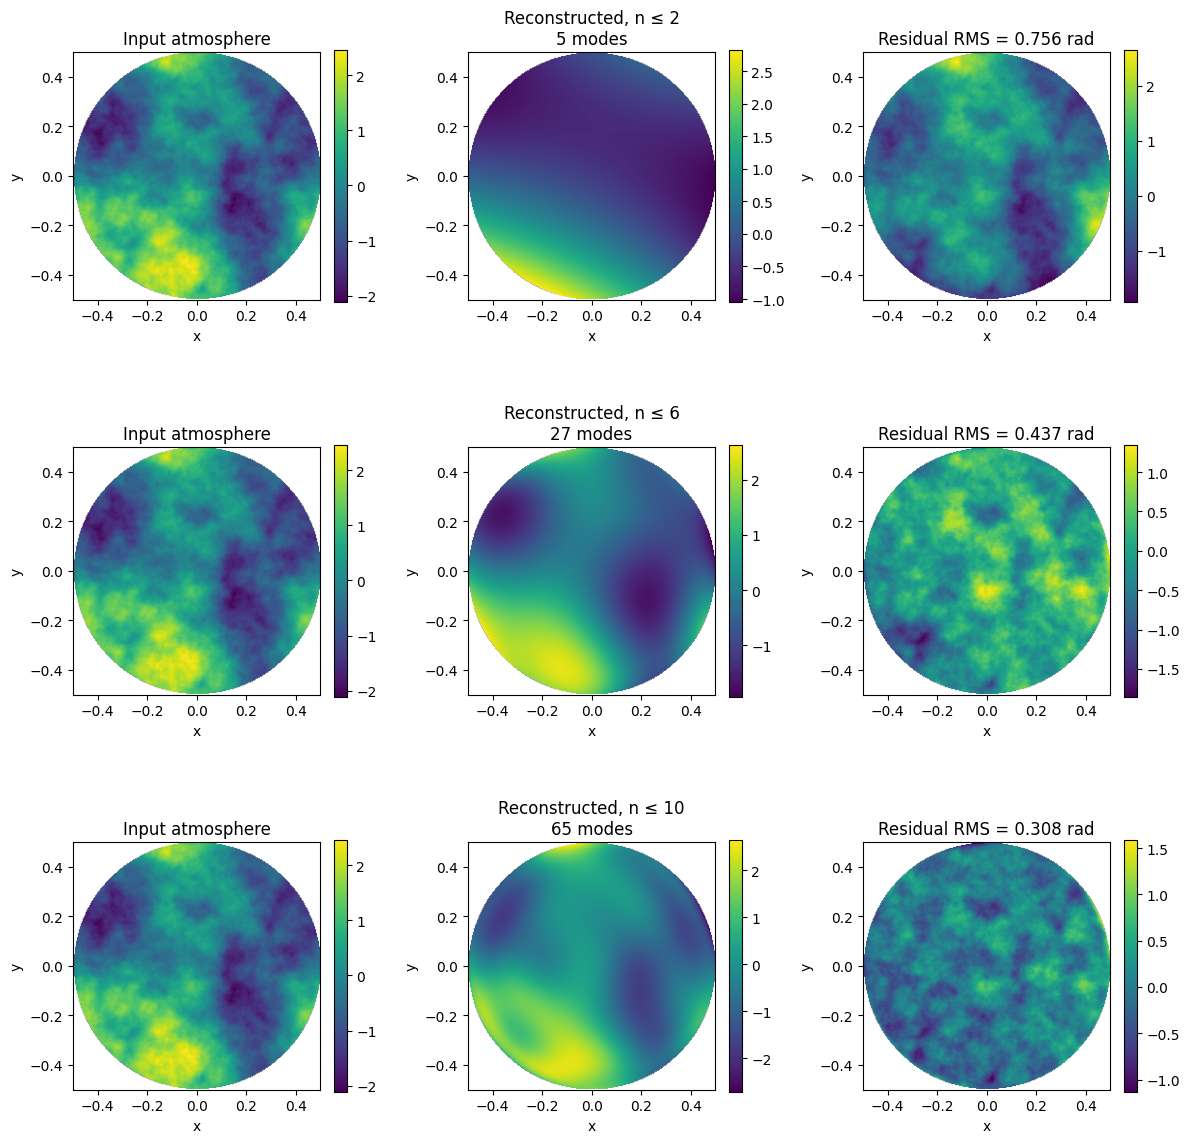

In [38]:
selected_indices = [0, len(results)//2, -1]

fig, axes = plt.subplots(len(selected_indices), 3, figsize=(12, 4 * len(selected_indices)))

for row, idx in enumerate(selected_indices):
    r = results[idx]

    max_order = max_orders[idx]
    W_rec = r["W_rec"]
    res = r["residual"]

    im0 = axes[row, 0].imshow(
        W_atm,
        extent=extent,
        origin="lower",
    )
    axes[row, 0].set_title("Input atmosphere")
    axes[row, 0].set_xlabel("x")
    axes[row, 0].set_ylabel("y")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(
        W_rec,
        extent=extent,
        origin="lower",
    )
    axes[row, 1].set_title(f"Reconstructed, n ≤ {max_order}\n{r['n_modes']} modes")
    axes[row, 1].set_xlabel("x")
    axes[row, 1].set_ylabel("y")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    im2 = axes[row, 2].imshow(
        res,
        extent=extent,
        origin="lower",
    )
    axes[row, 2].set_title(f"Residual RMS = {r['residual_rms']:.3f} rad")
    axes[row, 2].set_xlabel("x")
    axes[row, 2].set_ylabel("y")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

plt.tight_layout()
plt.show()

In [39]:
max_order_for_photon_scan = 8

modes_photon = generate_zernike_modes(
    rho,
    theta,
    mask,
    max_radial_order=max_order_for_photon_scan,
    include_piston=False,
    normalization=True,
)

A_det_photon, names_photon, centers_photon, masks_photon, reference_photon = (
    shwfs_detector.build_detector_response_matrix(
        modes_photon,
        mask,
        X,
        Y,
        n_lenslets=16,
        min_fill=0.5,
        pad_factor=4,
        threshold_fraction=0.02,
        subtract_minimum=True,
        detector_window_size=24,
        calibration_amplitude=1e-3,
        differential=True,
    )
)

print("Photon scan setup")
print("-----------------")
print(f"max_order = {max_order_for_photon_scan}")
print(f"n_modes   = {len(names_photon)}")
print(f"n_subap   = {len(centers_photon)}")
print(f"A shape   = {A_det_photon.shape}")

Photon scan setup
-----------------
max_order = 8
n_modes   = 44
n_subap   = 208
A shape   = (416, 44)


In [40]:
def photon_noise_scan_detector(
    W_true,
    mask,
    X,
    Y,
    modes,
    names,
    A_det,
    centers,
    masks_det,
    reference,
    photon_values,
    n_trials=10,
    n_lenslets=16,
    min_fill=0.5,
    pad_factor=4,
    read_noise_e=1.0,
    background_e=2.0,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    rcond=1e-3,
    seed=1,
):
    """
    Scan photons per subaperture per WFS frame and measure reconstruction quality.

    photons means detected photons/electrons per valid subaperture per frame.
    """
    rng = np.random.default_rng(seed)

    mean_residual = []
    std_residual = []
    median_residual = []
    mean_valid_fraction = []
    mean_coeff_norm = []

    for photons in photon_values:
        residuals = []
        valid_fractions = []
        coeff_norms = []

        for _ in range(n_trials):
            _, shifts, diag = shwfs_detector.measure_centroid_shifts(
                W_true,
                mask,
                X,
                Y,
                n_lenslets=n_lenslets,
                min_fill=min_fill,
                pad_factor=pad_factor,
                photons=float(photons),
                read_noise_e=read_noise_e,
                background_e=background_e,
                threshold_fraction=threshold_fraction,
                subtract_minimum=subtract_minimum,
                detector_window_size=detector_window_size,
                seed=int(rng.integers(0, 2**31 - 1)),
                reference=reference,
                masks=masks_det,
                centers=centers,
                return_diagnostics=True,
            )

            coeffs, residuals_lstsq, rank, singular_values = (
                shwfs_detector.reconstruct_from_centroid_shifts(
                    shifts,
                    A_det,
                    rcond=rcond,
                )
            )

            W_rec = synthesize_from_coefficients(
                coeffs,
                modes,
                names,
                mask,
                remove_mean=True,
            )

            res = residual_wavefront(W_true, W_rec, mask)

            residuals.append(rms(res, mask))
            valid_fractions.append(diag["n_valid"] / diag["n_total"])
            coeff_norms.append(np.linalg.norm(coeffs))

        residuals = np.asarray(residuals)
        valid_fractions = np.asarray(valid_fractions)
        coeff_norms = np.asarray(coeff_norms)

        mean_residual.append(np.mean(residuals))
        std_residual.append(np.std(residuals))
        median_residual.append(np.median(residuals))
        mean_valid_fraction.append(np.mean(valid_fractions))
        mean_coeff_norm.append(np.mean(coeff_norms))

        print(
            f"photons = {photons:8.0f}, "
            f"mean residual RMS = {np.mean(residuals):.4f} ± {np.std(residuals):.4f} rad, "
            f"valid = {np.mean(valid_fractions):.3f}"
        )

    return {
        "photon_values": np.asarray(photon_values, dtype=float),
        "mean_residual": np.asarray(mean_residual),
        "std_residual": np.asarray(std_residual),
        "median_residual": np.asarray(median_residual),
        "mean_valid_fraction": np.asarray(mean_valid_fraction),
        "mean_coeff_norm": np.asarray(mean_coeff_norm),
    }

In [41]:
photon_values = np.array([300, 500, 1000, 3000, 10000, 30000, 100000])

photon_scan = photon_noise_scan_detector(
    W_true=W_atm,
    mask=mask,
    X=X,
    Y=Y,
    modes=modes_photon,
    names=names_photon,
    A_det=A_det_photon,
    centers=centers_photon,
    masks_det=masks_photon,
    reference=reference_photon,
    photon_values=photon_values,
    n_trials=10,
    n_lenslets=16,
    min_fill=0.5,
    pad_factor=4,
    read_noise_e=1.0,
    background_e=2.0,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    rcond=1e-3,
    seed=42,
)

photons =      300, mean residual RMS = 3.7775 ± 0.0912 rad, valid = 1.000
photons =      500, mean residual RMS = 3.3068 ± 0.1035 rad, valid = 1.000
photons =     1000, mean residual RMS = 2.4709 ± 0.0849 rad, valid = 1.000
photons =     3000, mean residual RMS = 0.6983 ± 0.0361 rad, valid = 1.000
photons =    10000, mean residual RMS = 0.5010 ± 0.0072 rad, valid = 1.000
photons =    30000, mean residual RMS = 0.5010 ± 0.0031 rad, valid = 1.000
photons =   100000, mean residual RMS = 0.5021 ± 0.0010 rad, valid = 1.000


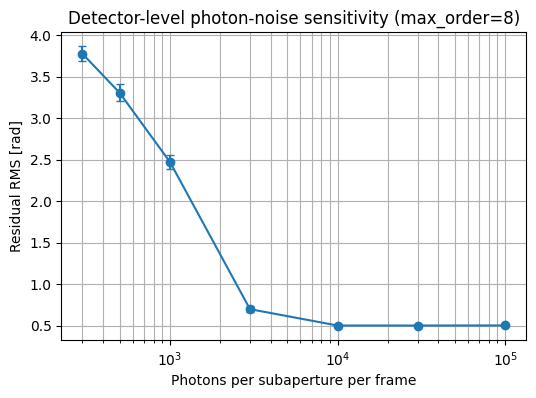

In [42]:
plt.figure(figsize=(6, 4))

plt.errorbar(
    photon_scan["photon_values"],
    photon_scan["mean_residual"],
    yerr=photon_scan["std_residual"],
    marker="o",
    capsize=3,
)

plt.xscale("log")
plt.xlabel("Photons per subaperture per frame")
plt.ylabel("Residual RMS [rad]")
plt.title(
    f"Detector-level photon-noise sensitivity "
    f"(max_order={max_order_for_photon_scan})"
)
plt.grid(True, which="both")
plt.show()

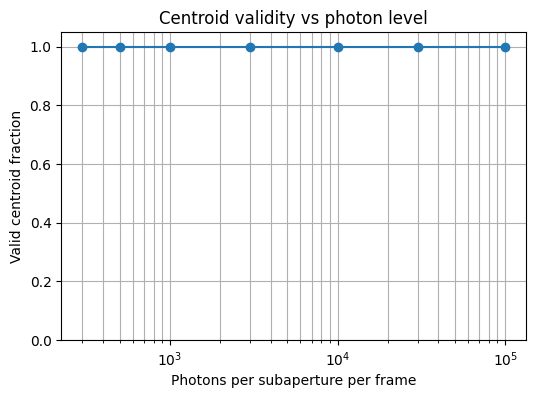

In [43]:
plt.figure(figsize=(6, 4))

plt.plot(
    photon_scan["photon_values"],
    photon_scan["mean_valid_fraction"],
    marker="o",
)

plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("Photons per subaperture per frame")
plt.ylabel("Valid centroid fraction")
plt.title("Centroid validity vs photon level")
plt.grid(True, which="both")
plt.show()

Noiseless detector-level residual RMS: 0.5012 rad


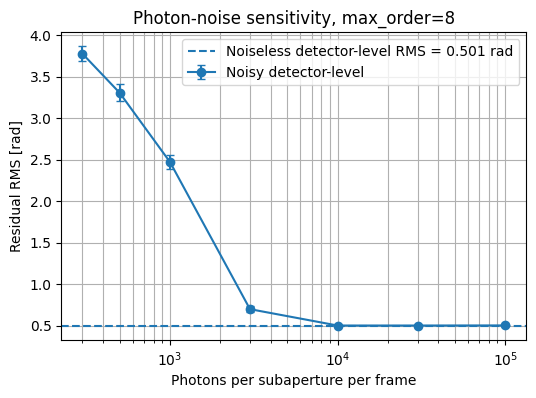

In [50]:
result_noiseless_photon_order = run_modal_reconstruction_with_max_order_detector(
    W_atm,
    X,
    Y,
    rho,
    theta,
    mask,
    max_radial_order=max_order_for_photon_scan,
    n_lenslets=16,
    photons=None,
    read_noise_e=0.0,
    background_e=0.0,
    pad_factor=4,
    threshold_fraction=0.02,
    subtract_minimum=True,
    detector_window_size=24,
    seed=1,
    rcond=1e-3,
)

noiseless_rms = result_noiseless_photon_order["residual_rms"]

plt.figure(figsize=(6, 4))

plt.errorbar(
    photon_scan["photon_values"],
    photon_scan["mean_residual"],
    yerr=photon_scan["std_residual"],
    marker="o",
    capsize=3,
    label="Noisy detector-level",
)

plt.axhline(
    noiseless_rms,
    linestyle="--",
    label=f"Noiseless detector-level RMS = {noiseless_rms:.3f} rad",
)

print(f"Noiseless detector-level residual RMS: {noiseless_rms:.4f} rad")
plt.xscale("log")
plt.xlabel("Photons per subaperture per frame")
plt.ylabel("Residual RMS [rad]")
plt.title(f"Photon-noise sensitivity, max_order={max_order_for_photon_scan}")
plt.grid(True, which="both")
plt.legend()
plt.show()

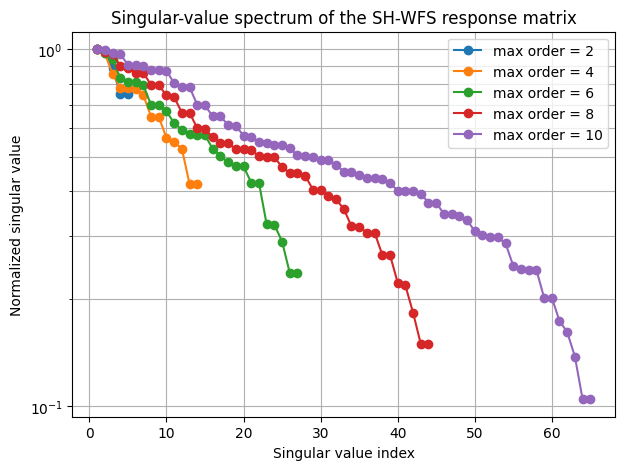

In [45]:
selected_orders = [2, 4, 6, 8, 10]

plt.figure(figsize=(7, 5))

for max_order in selected_orders:
    result = run_modal_reconstruction_with_max_order(
        W_atm,
        X,
        Y,
        rho,
        theta,
        mask,
        max_radial_order=max_order,
        n_lenslets=n_lenslets,
        noise_std=0.0,
        seed=1,
        rcond=1e-4,
    )

    svals = result["singular_values"]
    svals = svals / svals[0]

    plt.semilogy(
        np.arange(1, len(svals) + 1),
        svals,
        marker="o",
        label=f"max order = {max_order}"
    )

plt.xlabel("Singular value index")
plt.ylabel("Normalized singular value")
plt.title("Singular-value spectrum of the SH-WFS response matrix")
plt.grid(True, which="both")
plt.legend()
plt.show()

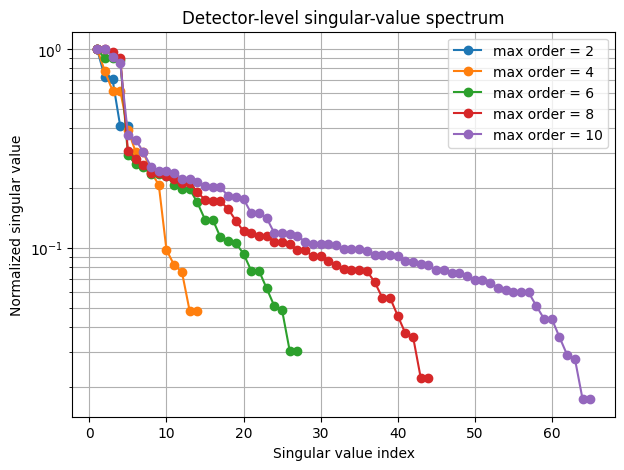

In [46]:
selected_orders = [2, 4, 6, 8, 10]

plt.figure(figsize=(7, 5))

for order in selected_orders:
    idx = list(max_orders_det).index(order)
    result = results_det[idx]

    svals = result["singular_values"]
    svals = svals / svals[0]

    plt.semilogy(
        np.arange(1, len(svals) + 1),
        svals,
        marker="o",
        label=f"max order = {order}",
    )

plt.xlabel("Singular value index")
plt.ylabel("Normalized singular value")
plt.title("Detector-level singular-value spectrum")
plt.grid(True, which="both")
plt.legend()
plt.show()

The condition number quantifies the numerical stability of the wavefront reconstruction problem. It is defined as the ratio between the largest and smallest singular values of the Shack-Hartmann response matrix. A low condition number means that all reconstructed modes are sensed with comparable sensitivity. A high condition number means that some modal combinations produce weak or nearly degenerate slope signals, so the inverse reconstruction can amplify noise.

As the maximum Zernike radial order increases, more high-spatial-frequency modes are included. These modes are harder to sample with a finite lenslet array and may produce similar averaged slope patterns. Therefore, the smallest singular values decrease and the condition number increases. This reflects the trade-off between fitting more atmospheric turbulence modes and maintaining a stable wavefront reconstruction.

In [47]:
strehl_values = []

for result in results:
    W_res = result["residual"]
    S = strehl_ratio(W_res, mask, pad_factor=4)
    strehl_values.append(S)

strehl_values = np.array(strehl_values)

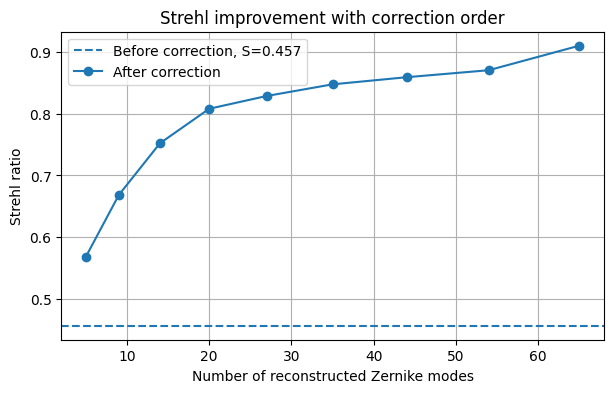

In [48]:
strehl_before = strehl_ratio(W_atm, mask, pad_factor=4)

plt.figure(figsize=(7, 4))

plt.axhline(
    strehl_before,
    linestyle="--",
    label=f"Before correction, S={strehl_before:.3f}",
)

plt.plot(
    n_modes,
    strehl_values,
    marker="o",
    label="After correction",
)

plt.xlabel("Number of reconstructed Zernike modes")
plt.ylabel("Strehl ratio")
plt.title("Strehl improvement with correction order")
plt.grid(True)
plt.legend()
plt.show()

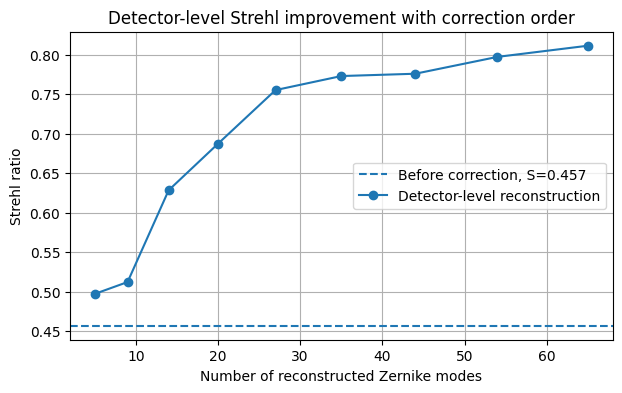

In [49]:
strehl_values_det = []

for result in results_det:
    W_res = result["residual"]
    S = strehl_ratio(W_res, mask, pad_factor=4)
    strehl_values_det.append(S)

strehl_values_det = np.array(strehl_values_det)
n_modes_det = np.array([r["n_modes"] for r in results_det])

strehl_before = strehl_ratio(W_atm, mask, pad_factor=4)

plt.figure(figsize=(7, 4))

plt.axhline(
    strehl_before,
    linestyle="--",
    label=f"Before correction, S={strehl_before:.3f}",
)

plt.plot(
    n_modes_det,
    strehl_values_det,
    marker="o",
    label="Detector-level reconstruction",
)

plt.xlabel("Number of reconstructed Zernike modes")
plt.ylabel("Strehl ratio")
plt.title("Detector-level Strehl improvement with correction order")
plt.grid(True)
plt.legend()
plt.show()

## Interpretation of the Zernike Mode-Order Scan

This notebook studies modal wavefront reconstruction using Zernike modes with increasing maximum radial order. The input wavefront is a controlled atmospheric phase screen with an RMS of approximately 1 rad inside the pupil. The phase screen follows a von Kármán / Kolmogorov-like spectral shape, but its RMS is normalized for a controlled reconstruction experiment. Therefore, the results should be interpreted as a wavefront-sensing and reconstruction study rather than a fully calibrated atmospheric seeing simulation.

The maximum Zernike radial order controls how many spatial modes are included in the reconstruction. Since piston is excluded, the number of reconstructed modes is

$$
N_{\mathrm{modes}} =
\frac{(n_{\max}+1)(n_{\max}+2)}{2} - 1 .
$$

For example, $n_{\max}=10$ corresponds to 65 reconstructed modes. Increasing the maximum radial order allows the reconstructor to describe progressively finer spatial structures in the phase screen. This should reduce the residual wavefront error, but it also makes the inverse problem more sensitive to measurement noise and numerical conditioning.

---

## Geometric Shack-Hartmann Baseline

The geometric Shack-Hartmann model uses an idealized measurement chain:

$$
\phi(x,y)
\rightarrow
\nabla \phi(x,y)
\rightarrow
\text{averaged subaperture slopes}.
$$

In this model, the wavefront sensor directly measures local phase gradients averaged over each subaperture. It does not include lenslet diffraction spots, finite detector pixels, photon noise, read noise, background, thresholding, detector windowing, or centroid bias. It is therefore best interpreted as an ideal reconstruction baseline.

The geometric reconstruction remains full-rank for all tested Zernike orders from $n_{\max}=2$ to $n_{\max}=10$. The rank is equal to the number of reconstructed modes throughout the scan, which means that all included modal degrees of freedom are distinguishable by the ideal slope-response matrix.

The residual RMS decreases from about 0.756 rad at $n_{\max}=2$ to about 0.308 rad at $n_{\max}=10$. This monotonic decrease is expected: higher-order Zernike modes capture more of the spatial structure in the atmospheric phase screen. At the same time, the condition number increases from about 1.3 to about 9.6. This indicates that the inverse problem becomes gradually less well-conditioned as more modes are included, but the geometric response matrix remains very stable in this range.

---

## Detector-Level Shack-Hartmann Reconstruction

The detector-level model replaces the ideal slope measurement with a more realistic measurement chain:

$$
\phi(x,y)
\rightarrow
\text{lenslet diffraction spots}
\rightarrow
\text{detector images}
\rightarrow
\text{centroid shifts}
\rightarrow
\text{modal reconstruction}.
$$

The response matrix is calibrated from centroid shifts rather than analytical slopes. This makes the reconstruction more realistic because it includes effects from finite spot size, pixel sampling, centroid estimation, detector thresholding, finite detector windows, photon statistics, read noise, and background.

The detector-level reconstruction also remains full-rank from $n_{\max}=2$ to $n_{\max}=10$. The number of valid centroids is 208/208 for all tested cases, which shows that all valid subapertures provide usable centroid measurements under the chosen detector settings.

Compared with the geometric case, the detector-level reconstruction has a larger residual RMS and a larger condition number. This is physically reasonable. The geometric model measures ideal local slopes, while the detector-level model estimates wavefront information indirectly through centroid shifts of finite diffraction spots. The detector-level condition number rises to roughly 40--60 at high radial order, but this is still a moderate value and does not indicate a severely ill-conditioned system. It mainly shows that realistic centroid-based reconstruction is more sensitive to measurement noise than the ideal geometric slope model.

The detector-level residual RMS decreases from about 0.839 rad at $n_{\max}=2$ to about 0.457 rad at $n_{\max}=10$. The improvement becomes slower beyond approximately $n_{\max}=7$ or $n_{\max}=8$, suggesting diminishing returns from adding more high-order modes under the current lenslet sampling and detector settings.

---

## Photon-Noise Sensitivity

The photon-noise scan fixes the reconstruction order at $n_{\max}=8$, corresponding to 44 Zernike modes. The detector-level response matrix has shape (416 \times 44), because there are 208 valid lenslets and each lenslet contributes two centroid-shift components.

The scan varies the number of detected photons per subaperture per frame. This is more realistic than adding arbitrary Gaussian noise to analytical slopes, because the noise is introduced at the detector-image level before centroiding.

At low photon counts, the reconstruction is strongly photon-limited. With 300--1000 photons per subaperture, the residual RMS becomes much larger than the input wavefront RMS. This means that the noisy centroid measurements are not just insufficient for correction; they can actively drive the modal reconstruction in the wrong direction and make the reconstructed wavefront worse.

At around 3000 photons per subaperture, the residual RMS drops to about 0.70 rad. At 10000 photons per subaperture and above, the residual RMS reaches a floor of about 0.50 rad. Increasing the photon count beyond this point does not significantly improve the reconstruction. This plateau indicates that the reconstruction is no longer photon-noise limited. The remaining error is dominated by modal fitting error, finite WFS spatial sampling, detector-level centroid response, and unmodelled high-spatial-frequency structure in the phase screen.

The valid centroid fraction remains equal to 1 across the photon scan. Therefore, the low-photon degradation is not caused by complete centroid failure. Instead, the centroids remain formally valid but become too noisy to support accurate modal reconstruction.

---

## Singular-Value Spectrum and Conditioning

The singular-value spectrum shows how strongly different modal combinations are sensed by the wavefront sensor. Large singular values correspond to well-measured modal directions, while small singular values correspond to weakly sensed or nearly degenerate combinations of modes.

As the maximum Zernike order increases, more high-spatial-frequency modes are added. These modes are harder to distinguish with a finite lenslet array and can produce more similar centroid-shift patterns. As a result, the smallest singular values decrease and the condition number increases.

This behavior reflects the central trade-off in modal wavefront reconstruction:

$$
\text{more modes}
\rightarrow
\text{better spatial fitting},
$$

but also

$$
\text{more modes}
\rightarrow
\text{stronger noise amplification}.
$$

The detector-level singular-value spectrum is less favorable than the geometric singular-value spectrum, which is expected because the detector-level model includes finite spot formation and centroid measurement effects. Nevertheless, the detector-level matrix remains full-rank and only moderately conditioned up to $n_{\max}=10$, so the reconstruction remains numerically usable.

---

## Strehl-Ratio Interpretation

The Strehl ratio is computed from the residual phase after modal correction. It measures the peak intensity of the corrected PSF relative to the diffraction-limited PSF. A lower residual RMS generally leads to a higher Strehl ratio.

Both the geometric and detector-level Strehl curves improve as the number of reconstructed modes increases. This is consistent with the residual RMS trends: removing more modal structure from the atmospheric phase screen leaves a smaller residual phase and produces a sharper PSF core.

The detector-level Strehl improvement is weaker than the geometric one because the detector-level residual RMS is larger. This is expected and reflects the fact that realistic centroid-based wavefront sensing is less ideal than direct analytical slope measurement.

These Strehl values should not be interpreted as a complete AO performance prediction. The simulation does not yet include closed-loop temporal control, servo lag, deformable-mirror fitting error, anisoplanatism, guide-star separation, or multi-layer turbulence. The Strehl analysis here is best understood as a static modal reconstruction metric.

---

## Overall Conclusion

The results are internally consistent and physically meaningful. The geometric reconstruction provides an ideal reference case, while the detector-level reconstruction introduces a more observation-like Shack-Hartmann measurement process. In both cases, increasing the Zernike reconstruction order reduces the residual wavefront error, and the response matrices remain full-rank up to $n_{\max}=10$.

The detector-level model shows the expected realism penalty: higher residual RMS, larger condition numbers, and stronger sensitivity to photon noise. The photon-noise scan clearly identifies a photon-limited regime at low flux and a reconstruction floor at high flux. This demonstrates that the notebook successfully goes beyond a toy analytical slope model and captures key observational limitations of Shack-Hartmann wavefront sensing.

A reasonable practical operating point for the current setup is around $n_{\max}=8$. At this order, the reconstruction includes 44 Zernike modes, remains full-rank, has a moderate condition number, and reaches the high-photon residual floor of approximately 0.50 rad. Higher orders can still reduce the residual RMS, but the gain becomes smaller and the inverse problem becomes more sensitive to measurement noise.
